In [248]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [249]:
# Thư mục chứa dữ liệu
folder_path = './Raw Data'

# Danh sách các file csv trong thư mục
csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

# Danh sách lưu dữ liệu từng file
dataframes = []

for file in csv_files:
    # Tách location và date từ tên file
    match = re.match(r'([A-Z]+)_(\d{1,2}-\d{1,2})', file)
    if match:
        location, date = match.groups()
    else:
        location, date = 'UNKNOWN', 'UNKNOWN'
    
    # Đọc file CSV
    df = pd.read_csv(os.path.join(folder_path, file))
    
    # Thêm cột location và date
    df['location'] = location
    df['date'] = date

    dataframes.append(df)

# Gộp tất cả các dataframe
merged_df = pd.concat(dataframes, ignore_index=True)

In [250]:
# Hiển thị vài dòng đầu
merged_df.head(5)

,name,address,review_score,review_count,Vị trí,Dịch vụ,Đáng giá tiền,Cơ sở vật chất,Độ sạch sẽ,bep,bua_sang,san_gon,may_giat,dua_don_san_bay,phong_tap,don_phong_hang_ngay,duoc_phep_mang_thu_nuoi,bai_do_xe,Giá trước,Giá sau,location,date,price,host_review_score
0,Thành Thuý Hotel (Thanh Thuy Hotel),"66 - 68 Điện Biên Phủ, Trung tâm thành phố Buô...","9,1",168,9.2,9.1,9.0,9.0,9.1,0,0,0,0,0,0,1,1,1,766.459,625.694,BMT,1-5,NaN,NaN
1,Muong Thanh Luxury Buon Ma Thuot Hotel,"Số 81 Nguyễn Tất Thành, Phường Tân An, Trung t...","8,7",2560,9.0,8.9,8.7,8.6,8.9,0,1,0,0,1,1,1,1,1,25.000.000,12.549.018,BMT,1-5,NaN,NaN
2,Khách sạn và Spa Hai Bà Trưng (Hai Ba Trung Ho...,"08, Đường Hai Bà Trưng, Trung tâm thành phố Bu...","8,2",399,9.0,8.6,7.9,7.7,8.2,0,1,0,0,1,1,1,1,1,1.017.217,912.069,BMT,1-5,NaN,NaN
3,The Coffee City - Healing & Retreats,"Robusta, Nguyen Dinh Chieu, Buon Ma Thuot City...","8,3",311,8.6,8.8,8.0,8.3,9.1,1,1,1,1,1,1,1,1,1,Không có giá trước,Không có giá sau,BMT,1-5,NaN,NaN
4,Nhà Nghỉ Thượng Phong (Thuong Phong Motel),"Thái Phiên, Trung tâm thành phố Buôn Ma Thuột,...","8,1",778,8.3,8.4,8.4,7.7,8.1,0,0,0,0,0,0,0,1,0,1.004.424,336.343,BMT,1-5,NaN,NaN


In [251]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17929 entries, 0 to 17928
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   name                     17929 non-null  object
 1   address                  17929 non-null  object
 2   review_score             17929 non-null  object
 3   review_count             17929 non-null  object
 4   Vị trí                   17929 non-null  object
 5   Dịch vụ                  17929 non-null  object
 6   Đáng giá tiền            17929 non-null  object
 7   Cơ sở vật chất           17929 non-null  object
 8   Độ sạch sẽ               17929 non-null  object
 9   bep                      17929 non-null  int64 
 10  bua_sang                 17929 non-null  int64 
 11  san_gon                  17929 non-null  int64 
 12  may_giat                 17929 non-null  int64 
 13  dua_don_san_bay          17929 non-null  int64 
 14  phong_tap                17929 non-nul

In [252]:
merged_df.drop_duplicates(inplace=True)

In [253]:
merged_df.reset_index(drop=True, inplace=True)

In [254]:
# Xóa những cột không cần thiết vì thiếu nhiều dữ liệu
columns_to_drop = ['price', 'host_review_score']
merged_df.drop(columns=columns_to_drop, inplace=True)

Tạo cột dữ liệu mới cột dữ liệu 'full' để biết được khách sạn đó còn phòng hay không

In [255]:
# Nếu khách sạn không có giá trước, lẫn giá sau thì hết phòng
# Đánh dấu: 1 = hết phòng, 0 = còn phòng

# Chuyển "Không có" thành NaN trong 2 cột giá
merged_df['Giá trước'] = merged_df['Giá trước'].replace('Không có giá trước', np.nan)
merged_df['Giá sau'] = merged_df['Giá sau'].replace('Không có giá sau', np.nan)

# Đánh dấu khách sạn hết phòng: nếu cả 2 giá đều thiếu
merged_df['full'] = ((merged_df['Giá trước'].isna()) & (merged_df['Giá sau'].isna())).astype(int)

In [256]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16270 entries, 0 to 16269
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   name                     16270 non-null  object
 1   address                  16270 non-null  object
 2   review_score             16270 non-null  object
 3   review_count             16270 non-null  object
 4   Vị trí                   16270 non-null  object
 5   Dịch vụ                  16270 non-null  object
 6   Đáng giá tiền            16270 non-null  object
 7   Cơ sở vật chất           16270 non-null  object
 8   Độ sạch sẽ               16270 non-null  object
 9   bep                      16270 non-null  int64 
 10  bua_sang                 16270 non-null  int64 
 11  san_gon                  16270 non-null  int64 
 12  may_giat                 16270 non-null  int64 
 13  dua_don_san_bay          16270 non-null  int64 
 14  phong_tap                16270 non-nul

## Nhận xét:
- Giá trước và giá sau thiếu giá trị vì có những khách sạn chỉ có giá sau(Không giảm giá), hoặc là hết phòng(Thiếu cả hai).
- Những điểm không thiếu giá trị bởi vì nếu không thu thập được thì sẽ điền là không có vì vậy phải xử lý cái này.
- Những điểm tiện nghi do trong web crawling mặc định là 0 nên nó sẽ không bị thiếu giá trị.

## Xử lý các giá trị không có

In [257]:
# Cột đánh giá cần xử lý
cols_to_fill = ['review_score', 'review_count', 'Vị trí', 'Dịch vụ', 'Đáng giá tiền', 'Cơ sở vật chất', 'Độ sạch sẽ']

# Thay toàn bộ "Không có" bằng np.nan để xử lý thiếu thống nhất
for col in cols_to_fill:
    merged_df[col] = merged_df[col].replace(r'^Không có.*', np.nan, regex=True)

# Hàm kiểm tra dòng thiếu toàn bộ các cột đánh giá
def is_all_missing(row):
    return row[cols_to_fill].isna().all()

# Ép kiểu các cột về số (sau khi đã thay "Không có")
for col in cols_to_fill:
    merged_df[col] = pd.to_numeric(merged_df[col].astype(str).str.replace(',', '.'), errors='coerce')

In [258]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16270 entries, 0 to 16269
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     16270 non-null  object 
 1   address                  16270 non-null  object 
 2   review_score             12915 non-null  float64
 3   review_count             12915 non-null  float64
 4   Vị trí                   12719 non-null  float64
 5   Dịch vụ                  12753 non-null  float64
 6   Đáng giá tiền            12666 non-null  float64
 7   Cơ sở vật chất           12205 non-null  float64
 8   Độ sạch sẽ               12758 non-null  float64
 9   bep                      16270 non-null  int64  
 10  bua_sang                 16270 non-null  int64  
 11  san_gon                  16270 non-null  int64  
 12  may_giat                 16270 non-null  int64  
 13  dua_don_san_bay          16270 non-null  int64  
 14  phong_tap             

## Nhận xét:
 Sau khi xử lý không có thay bằng NaN, thì những điểm giá trị bị thiếu: Có 2 trường hợp xảy ra
 - Trường hợp 1: Web Crawling cào thiếu (Hiếm khi)
 - Trường hợp 2: Các khách sạn đó chưa được đặt bao giờ.

## Trực quan hóa dữ liệu để điền giá trị thiếu phù hợp

Những giá trị thiếu bao gồm: review_score, review_count, Vị trí, Dịch vụ, Đáng giá tiền, Cơ sở vật chất, Độ sạch sẽ, Giá trước, Giá sau         


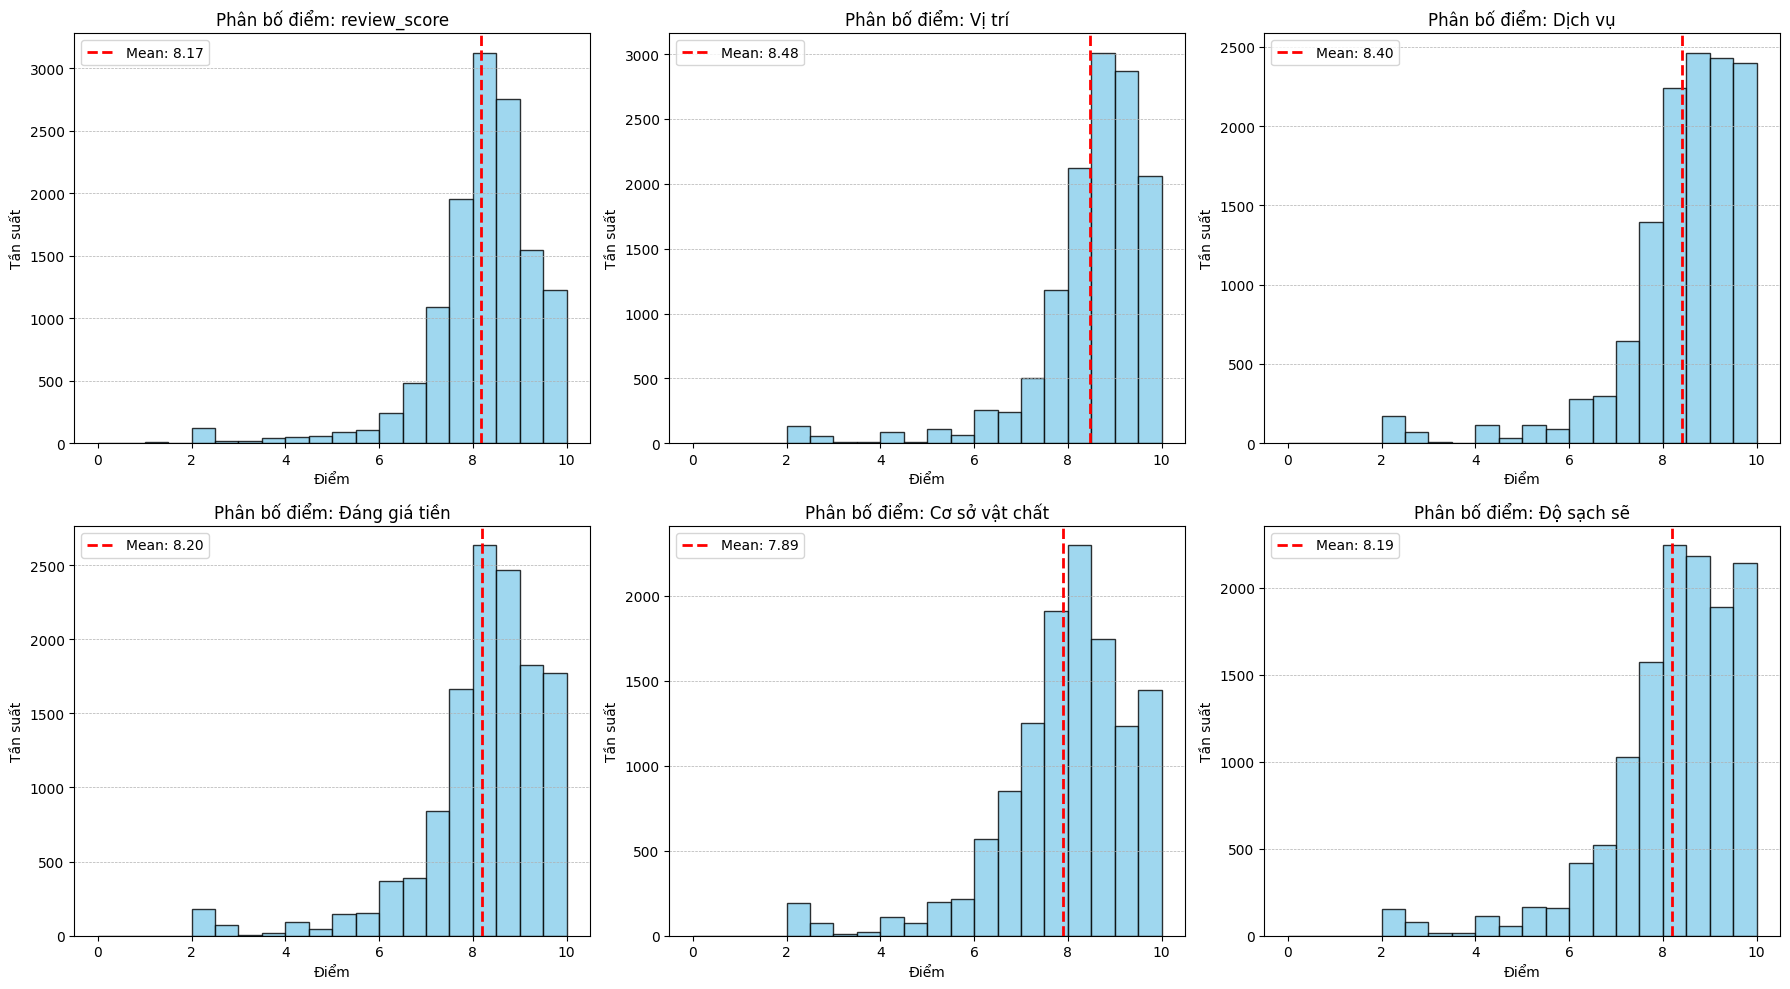

In [261]:
# Danh sách các cột đánh giá
cols_to_plot = ['review_score', 'Vị trí', 'Dịch vụ', 'Đáng giá tiền', 'Cơ sở vật chất', 'Độ sạch sẽ']

# Thiết lập kích thước hình vẽ
plt.figure(figsize=(18, 10))

# Duyệt từng cột và vẽ histogram
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 3, i)
    data = merged_df[col].dropna()

    # Vẽ histogram
    plt.hist(data, bins=20, range=(0, 10), color='skyblue', edgecolor='black', alpha=0.8)

    # Vẽ đường trung bình
    mean_val = data.mean()
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')

    # Giao diện biểu đồ
    plt.title(f'Phân bố điểm: {col}', fontsize=12)
    plt.xlabel('Điểm')
    plt.ylabel('Tần suất')
    plt.grid(axis='y', linestyle='--', linewidth=0.5)
    plt.legend()

plt.tight_layout()
plt.show()

Dựa trên biểu đồ phân bố điểm đánh giá của các tiêu chí (review_score, Vị trí, Dịch vụ, Đáng giá tiền, Cơ sở vật chất, Độ sạch sẽ), có thể đưa ra các nhận xét sau:

1. Điểm số trung bình khá cao toàn diện
- Tất cả các tiêu chí đều có điểm trung bình từ khoảng 7.8 đến 8.5, cho thấy khách sạn trong tập dữ liệu được đánh giá tương đối tốt.
- Không có tiêu chí nào bị tụt dưới ngưỡng trung bình (dưới 7), điều này phản ánh chất lượng chung tương đối đồng đều và ổn định.
2. Phân bố lệch phải rõ rệt
- Các biểu đồ đều lệch phải (right-skewed), tức là phần lớn khách sạn được đánh giá cao (8–10), rất ít khách sạn có điểm thấp.
- Đặc biệt là cột Dịch vụ, Vị trí, Độ sạch sẽ: hầu hết các khách sạn tập trung ở mức điểm 8–10.
- Một số tiêu chí như Cơ sở vật chất có phân bố rộng hơn, tức là mức độ đánh giá của người dùng về tiêu chí này đa dạng hơn và có nhiều khách sạn bị đánh giá thấp hơn so với các tiêu chí còn lại.
3. Dữ liệu sạch, không có outlier lớn
- Các histogram không cho thấy sự xuất hiện rõ rệt của outliers nghiêm trọng, ngoại trừ một số điểm cực thấp rải rác (0–2) ở vài biểu đồ.
- Có thể cân nhắc xem xét kỹ các khách sạn có điểm số thấp bất thường (có thể do lỗi nhập hoặc thực sự chất lượng kém).


In [262]:
merged_df.describe()

,review_score,review_count,Vị trí,Dịch vụ,Đáng giá tiền,Cơ sở vật chất,Độ sạch sẽ,bep,bua_sang,san_gon,may_giat,dua_don_san_bay,phong_tap,don_phong_hang_ngay,duoc_phep_mang_thu_nuoi,bai_do_xe,full
count,12915.000000,12915.000000,12719.000000,12753.000000,12666.000000,12205.000000,12758.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000
mean,8.168974,731.493535,8.480588,8.400306,8.197466,7.890569,8.187482,0.690412,0.242963,0.111616,0.392440,0.371051,0.346835,0.533866,0.770129,0.665888,0.195698
std,1.198937,1566.093322,1.289964,1.407155,1.412069,1.498237,1.462084,0.462338,0.428886,0.314904,0.488309,0.483101,0.475977,0.498867,0.420763,0.471694,0.396749
min,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.700000,17.000000,8.000000,7.900000,7.700000,7.300000,7.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,8.300000,158.000000,8.700000,8.600000,8.400000,8.000000,8.400000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
75%,8.900000,688.000000,9.200000,9.300000,9.000000,8.800000,9.100000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,10.000000,25251.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Xử lý giá trị thiếu

Xử lý giá trước và giá sau: 
1. Giá trước (giá chưa giảm): Nếu có giá trị, đây là giá gốc. Nếu thiếu, có thể hiểu là không có giảm giá (giá trước = giá sau).
2. Giá sau (giá đã giảm): Nếu thiếu, có thể do lỗi thu thập dữ liệu. Nếu có mà không có Giá trước, thì Giá trước nên được gán bằng Giá sau (vì không có giảm giá).
3. Trường hợp cả hai đều thiếu: Đã được xử lý trong notebook bằng cột full (1 = hết phòng, 0 = còn phòng).

In [263]:
def clean_price_column(series):
    return (
        series.astype(str)
              .str.replace(r"[^\d]", "", regex=True)  # loại bỏ ký tự không phải số
              .replace("", "0")                       # nếu rỗng thì gán là 0
              .astype(float)
    )

merged_df['Giá trước'] = clean_price_column(merged_df['Giá trước'])
merged_df['Giá sau'] = clean_price_column(merged_df['Giá sau'])

# Sau đó xử lý thiếu
merged_df['Giá trước'] = merged_df['Giá trước'].fillna(merged_df['Giá sau'])
merged_df['Giá trước'] = merged_df['Giá trước'].fillna(0)
merged_df['Giá sau'] = merged_df['Giá sau'].fillna(0)

 Xử lý các điểm đánh giá, số lượng review thiếu: 
1. Vì cào trong nhiều ngày nên các điểm dữ liệu thiếu của khách sạn có thể là do Web Crawling, nếu khách sạn có vào ngày khác, ta có thể dùng các điểm hay số lượng đặt của khách sạn đó bù cho dữ liệu bị thiếu
2. Với những khách sạn chưa bao giờ được đặt, hoặc không trong trường hợp trên, xử lý như sau:
  - Dựa vào biểu đồ trên, có thể thấy mean của các điểm đánh giá này rất cao từ 7.8 đến 8.5, nếu mà ta điền điểm giá trị mean vào dữ liệu thiếu thì nó sẽ không được công bằng cho những khách sạn khác vì 7.8 đến 8.5 là điểm số khá là cao và từ khoảng 25% nó vẫn cao nên bỏ qua
  - Còn min thì hơi thấp, nếu mà điền thấp quá thì nếu điểm giá trị thấp thì những khách sạn này sẽ khó được ưu tiên mặc dù đúng gu khách hàng(Vì điểm giá trị thực phụ thuộc vào 2 thứ: Điểm đánh giá và số lượng đánh giá, thích hợp với sở thích khách hàng).  
  - Chốt lại vậy nên quyết định là chọn điền 5 cho các điểm đánh giá, để nếu khi khách sạn nâng cấp dịch vụ hoặc giảm giá thì sẽ có cơ hội được ưu tiên cho khách hàng.
3. Với số lượng đánh giá thì điền 0

In [264]:
# Duyệt từng dòng
for idx, row in merged_df.iterrows():
    if is_all_missing(row):
        hotel = row.get('name')
        location = row.get('location')

        # Tìm các dòng trùng hotel_name & location, không phải chính nó
        similar_rows = merged_df[
            (merged_df['name'] == hotel) &
            (merged_df['location'] == location) &
            (merged_df.index != idx)
        ]
        
        found = False
        for _, ref_row in similar_rows.iterrows():
            if not is_all_missing(ref_row):
                for col in cols_to_fill:
                    merged_df.at[idx, col] = ref_row[col]
                found = True
                break
        
        # Nếu không tìm thấy dòng nào có dữ liệu → gán mặc định
        if not found:
            merged_df.at[idx, 'review_count'] = 0
            for col in ['review_score', 'Vị trí', 'Dịch vụ', 'Đáng giá tiền', 'Cơ sở vật chất', 'Độ sạch sẽ']:
                merged_df.at[idx, col] = 5

# Kiểm tra lại có còn dòng nào thiếu toàn bộ không
still_missing = merged_df[merged_df[cols_to_fill].isna().all(axis=1)]
print("Số dòng vẫn còn thiếu toàn bộ:", len(still_missing))

Số dòng vẫn còn thiếu toàn bộ: 0


In [265]:
# Sau khi xử lý toàn bộ dòng thiếu, xử lý tiếp các giá trị thiếu riêng lẻ
merged_df[cols_to_fill] = merged_df[cols_to_fill].fillna({
    'review_score': 5,
    'review_count': 0,
    'Vị trí': 5,
    'Dịch vụ': 5,
    'Đáng giá tiền': 5,
    'Cơ sở vật chất': 5,
    'Độ sạch sẽ': 5
})

In [266]:
merged_df.describe()

,review_score,review_count,Vị trí,Dịch vụ,Đáng giá tiền,Cơ sở vật chất,Độ sạch sẽ,bep,bua_sang,san_gon,may_giat,dua_don_san_bay,phong_tap,don_phong_hang_ngay,duoc_phep_mang_thu_nuoi,bai_do_xe,Giá trước,Giá sau,full
count,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,16270.000000,1.627000e+04,1.627000e+04,16270.000000
mean,7.531936,580.743208,7.736638,7.680744,7.501961,7.181328,7.513411,0.690412,0.242963,0.111616,0.392440,0.371051,0.346835,0.533866,0.770129,0.665888,1.956936e+06,1.761869e+06,0.195698
std,1.668567,1426.315610,1.835579,1.874946,1.825980,1.810268,1.846153,0.462338,0.428886,0.314904,0.488309,0.483101,0.475977,0.498867,0.420763,0.471694,1.118934e+07,8.971942e+06,0.396749
min,1.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,6.500000,1.000000,6.000000,6.000000,5.300000,5.000000,5.525000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,3.176645e+05,0.000000
50%,8.000000,59.000000,8.400000,8.300000,8.000000,7.600000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,5.168915e+05,6.609510e+05,0.000000
75%,8.700000,457.750000,9.100000,9.100000,8.800000,8.600000,9.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.762089e+06,1.440550e+06,0.000000
max,10.000000,25251.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.775360e+08,2.327976e+08,1.000000


## Đổi lại tên cho nhất quán.

In [267]:
# Đổi tên các cột sang dạng không dấu, viết thường, có gạch dưới
merged_df.rename(columns={
    'name': 'ten',
    'address': 'dia_chi',
    'review_score': 'diem_danh_gia',
    'review_count': 'so_luong_danh_gia',
    'Vị trí': 'vi_tri',
    'Dịch vụ': 'dich_vu',
    'Đáng giá tiền': 'dang_gia_tien',
    'Cơ sở vật chất': 'co_so_vat_chat',
    'Độ sạch sẽ': 'do_sach_se',
    'bep': 'bep',
    'bua_sang': 'bua_sang',
    'san_gon': 'san_gon',
    'may_giat': 'may_giat',
    'dua_don_san_bay': 'dua_don_san_bay',
    'phong_tap': 'phong_tap',
    'don_phong_hang_ngay': 'don_phong_hang_ngay',
    'duoc_phep_mang_thu_nuoi': 'thu_nuoi',
    'bai_do_xe': 'bai_do_xe',
    'Giá trước': 'gia_truoc',
    'Giá sau': 'gia_sau',
    'location': 'vi_tri_map',
    'date': 'ngay',
    'full': 'het_phong'
}, inplace=True)

# Kiểm tra lại tên các cột sau khi đổi
print(merged_df.columns.tolist())

['ten', 'dia_chi', 'diem_danh_gia', 'so_luong_danh_gia', 'vi_tri', 'dich_vu', 'dang_gia_tien', 'co_so_vat_chat', 'do_sach_se', 'bep', 'bua_sang', 'san_gon', 'may_giat', 'dua_don_san_bay', 'phong_tap', 'don_phong_hang_ngay', 'thu_nuoi', 'bai_do_xe', 'gia_truoc', 'gia_sau', 'vi_tri_map', 'ngay', 'het_phong']


In [268]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16270 entries, 0 to 16269
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ten                  16270 non-null  object 
 1   dia_chi              16270 non-null  object 
 2   diem_danh_gia        16270 non-null  float64
 3   so_luong_danh_gia    16270 non-null  float64
 4   vi_tri               16270 non-null  float64
 5   dich_vu              16270 non-null  float64
 6   dang_gia_tien        16270 non-null  float64
 7   co_so_vat_chat       16270 non-null  float64
 8   do_sach_se           16270 non-null  float64
 9   bep                  16270 non-null  int64  
 10  bua_sang             16270 non-null  int64  
 11  san_gon              16270 non-null  int64  
 12  may_giat             16270 non-null  int64  
 13  dua_don_san_bay      16270 non-null  int64  
 14  phong_tap            16270 non-null  int64  
 15  don_phong_hang_ngay  16270 non-null 

## Lưu thành file Silver

In [269]:
# Lưu ra file mới
merged_df.to_csv('Silver_Data.csv', index=False)
print("✅ Đã lưu kết quả vào Silver_Data.csv")

✅ Đã lưu kết quả vào Silver_Data.csv


## Chuyển sang Gold Data

In [270]:
# Xóa những cột không cần thiết
columns_to_drop = ['gia_truoc']
merged_df.drop(columns=columns_to_drop, inplace=True)

## Tính giá trị thực cho các khách hàng mới

In [271]:
# Bỏ trùng tên khách sạn
hotel_df = merged_df.drop_duplicates(subset='ten', keep='first')

# Các tham số cho công thức Netflix
R = hotel_df['diem_danh_gia']
v = hotel_df['so_luong_danh_gia']
C = hotel_df['diem_danh_gia'].mean()
m = hotel_df['so_luong_danh_gia'].quantile(0.75)

# Tính điểm theo Bayesian Rating (Netflix-style)
hotel_df['gia_tri_thuc_netflix'] = ((v / (v + m)) * R + (m / (v + m)) * C).round(2)

# Gán lại giá trị này về merged_df thông qua cột 'ten'
merged_df = merged_df.merge(
    hotel_df[['ten', 'gia_tri_thuc_netflix']],
    on='ten',
    how='left',
    suffixes=('', '_new')
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_4440\1015755860.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hotel_df['gia_tri_thuc_netflix'] = ((v / (v + m)) * R + (m / (v + m)) * C).round(2)


In [272]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16270 entries, 0 to 16269
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ten                   16270 non-null  object 
 1   dia_chi               16270 non-null  object 
 2   diem_danh_gia         16270 non-null  float64
 3   so_luong_danh_gia     16270 non-null  float64
 4   vi_tri                16270 non-null  float64
 5   dich_vu               16270 non-null  float64
 6   dang_gia_tien         16270 non-null  float64
 7   co_so_vat_chat        16270 non-null  float64
 8   do_sach_se            16270 non-null  float64
 9   bep                   16270 non-null  int64  
 10  bua_sang              16270 non-null  int64  
 11  san_gon               16270 non-null  int64  
 12  may_giat              16270 non-null  int64  
 13  dua_don_san_bay       16270 non-null  int64  
 14  phong_tap             16270 non-null  int64  
 15  don_phong_hang_ngay

In [273]:
# Chọn các tiện nghi làm feature
features = [
    'bep', 'bua_sang', 'san_gon', 
    'may_giat', 'dua_don_san_bay', 'phong_tap', 'don_phong_hang_ngay', 
    'thu_nuoi', 'bai_do_xe'
]

In [274]:
X = merged_df[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [275]:
# Người dùng nhập danh sách thích / không thích
yeu_thich = ['KHÁCH SẠN LA VELA SÀI GÒN (LA VELA SAIGON HOTEL)', 'KHÁCH SẠN LA VELA SÀI GÒN (LA VELA SAIGON HOTEL)', 'Hotel Continental Saigon', 'COCHIN SANG HOTEL']
khong_thich = ['Khách sạn Minh Anh Gò Vấp (Khách sạn Minh Anh Gò Vấp )', 'Khách Sạn Mari Queen (Mari Queen Hotel)']

merged_df['target'] = 0
merged_df.loc[merged_df['ten'].isin(yeu_thich), 'target'] = 1
merged_df.loc[merged_df['ten'].isin(khong_thich), 'target'] = -1

In [276]:
# Gom cụm khách sạn theo tiện nghi (KMeans)
kmeans = KMeans(n_clusters=4, random_state=42)
merged_df['cluster'] = kmeans.fit_predict(X_scaled)

In [277]:
# Đánh giá cụm nào giống "gu thích" hay "không thích"
def danh_gia_cum(cum_df):
    if (cum_df['target'] == 1).sum() > (cum_df['target'] == -1).sum():
        return 'GẦN GU THÍCH'
    elif (cum_df['target'] == -1).sum() > (cum_df['target'] == 1).sum():
        return 'KHÔNG HỢP GU'
    else:
        return 'TRUNG LẬP'

merged_df['cum_danh_gia'] = merged_df.groupby('cluster')['target'].transform(lambda x: danh_gia_cum(merged_df.loc[x.index]))

In [278]:
# Tạo phiên bản "khuếch đại gu" để huấn luyện Ridge
merged_df['target_khuech_dai'] = merged_df['target']
merged_df.loc[merged_df['cum_danh_gia'] == 'GẦN GU THÍCH', 'target_khuech_dai'] = 1
merged_df.loc[merged_df['cum_danh_gia'] == 'KHÔNG HỢP GU', 'target_khuech_dai'] = -1

In [279]:
# Huấn luyện mô hình Ridge để học gu từ các tiện nghi
model = Ridge(alpha=1.0)
model.fit(X_scaled, merged_df['target_khuech_dai'])

Ridge()

In [280]:
# Phân tích trọng số các tiện nghi theo gu người dùng 
feature_weights = pd.Series(model.coef_, index=features).sort_values(ascending=False)
print("🔍 Trọng số các tiện nghi phản ánh gu khách hàng:")
print(feature_weights)

🔍 Trọng số các tiện nghi phản ánh gu khách hàng:
bua_sang               0.424712
san_gon                0.244314
dua_don_san_bay        0.126098
may_giat               0.122847
phong_tap              0.109568
bep                   -0.059474
bai_do_xe             -0.076642
thu_nuoi              -0.099431
don_phong_hang_ngay   -0.168169
dtype: float64


In [281]:
# Dự đoán mức độ phù hợp của từng khách sạn
merged_df['gia_tri_thuc_ridge'] = model.predict(X_scaled)
scaler = MinMaxScaler(feature_range=(0, 10))
merged_df['gia_tri_thuc_ridge_scaled'] = scaler.fit_transform(merged_df[['gia_tri_thuc_ridge']])

merged_df['goi_y'] = np.tanh(merged_df['gia_tri_thuc_ridge'])  # Chuẩn hóa nhẹ về [-1, 1]
merged_df['gia_tri_thuc'] = 0.5 * merged_df['gia_tri_thuc_ridge'] + 0.5 * merged_df['gia_tri_thuc_netflix']
scaler_final = MinMaxScaler(feature_range=(0, 10))
merged_df['gia_tri_thuc'] = scaler_final.fit_transform(merged_df[['gia_tri_thuc']]).round(2)

In [282]:
# In danh sách khách sạn KHÁC (không trùng tên)
khach_san_khac = (
    merged_df[merged_df['target'] == 0]  # Không nằm trong danh sách thích/không thích
    [['ten', 'goi_y', 'cum_danh_gia']]
    .drop_duplicates(subset='ten')  # Loại bỏ khách sạn trùng tên
    .sort_values(by='goi_y', ascending=False)
)

In [283]:
print("📋 Danh sách KHÁCH SẠN KHÁC (không trùng tên):")
print(khach_san_khac.head(10))  # In top 10 gợi ý khác nhau

📋 Danh sách KHÁCH SẠN KHÁC (không trùng tên):
                                                     ten     goi_y  \
12982                                MIDTOWN Grand Elite  0.952085   
2529   Sens House Saigon - Căn Hộ Dịch Vụ Vinhomes Ce...  0.952085   
4402            The Lancaster Lê Thánh Tôn Apartments D1  0.952085   
6092   Căn hộ cao cấp - Vinhomes Central Park (Vinhom...  0.952085   
2329                      LANDMARK 81 Skyline Residences  0.952085   
4418                               LANDMARK 81 RESIDENCE  0.952085   
4417                     Landmark 81 Residence Signature  0.952085   
4062        Landmark 81 and Vinhomes Riverside Residence  0.952085   
2656   Landmark 81 And Vinhomes PANORAMA - ANGIA Hosp...  0.952085   
2587         Landmark 81 & Vinhomes Royal City Apartment  0.952085   

       cum_danh_gia  
12982  GẦN GU THÍCH  
2529   GẦN GU THÍCH  
4402   GẦN GU THÍCH  
6092   GẦN GU THÍCH  
2329   GẦN GU THÍCH  
4418   GẦN GU THÍCH  
4417   GẦN GU THÍCH  
4062   

## Xóa những cột không cần thiết

In [284]:
columns_to_drop = ['target', 'target_khuech_dai', 'cum_danh_gia', 'cluster', 'gia_tri_thuc_ridge', 'gia_tri_thuc_ridge_scaled', 'gia_tri_thuc_netflix', 'goi_y']
merged_df.drop(columns=columns_to_drop, inplace=True)

In [285]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16270 entries, 0 to 16269
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ten                  16270 non-null  object 
 1   dia_chi              16270 non-null  object 
 2   diem_danh_gia        16270 non-null  float64
 3   so_luong_danh_gia    16270 non-null  float64
 4   vi_tri               16270 non-null  float64
 5   dich_vu              16270 non-null  float64
 6   dang_gia_tien        16270 non-null  float64
 7   co_so_vat_chat       16270 non-null  float64
 8   do_sach_se           16270 non-null  float64
 9   bep                  16270 non-null  int64  
 10  bua_sang             16270 non-null  int64  
 11  san_gon              16270 non-null  int64  
 12  may_giat             16270 non-null  int64  
 13  dua_don_san_bay      16270 non-null  int64  
 14  phong_tap            16270 non-null  int64  
 15  don_phong_hang_ngay  16270 non-null 

In [286]:
# Lưu kết quả vào file CSV
merged_df.to_csv('Gold_Data.csv', index=False)
print("✅ Đã lưu kết quả vào Gold_Data.csv")

✅ Đã lưu kết quả vào Gold_Data.csv
